<a href="https://colab.research.google.com/github/BhavikBuchke/Cisco-Data-science-program/blob/main/Data%20modeling/Blood%20Pressure%20Project/blood%20pressure.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Blood Pressure

Does blood pressure increase with age?

The `blood-pressure-usa.csv` file contains systolic blood pressure readings from 100 individuals sampled by the National Health and Nutrition Examination Survey (NHANES) in the U.S., with each person measured three times.

The `blood-pressure-yanomami.csv` file features systolic blood pressure data from 71 individuals of the Yanomami Tribe, who live in near-total isolation in the Amazon.

While the average American consumes about 3,500 mg of sodium daily (from salt), the Yanomami's intake is estimated to be less than 100 mg.

In [ ]:
# FOR GOOGLE COLAB ONLY.
# Uncomment and run the code below. A dialog will appear to upload files.
# Upload 'blood-pressure-usa.csv', 'blood-pressure-yanomami.csv', and 'linear_model.py'.

from google.colab import files
uploaded = files.upload()

Saving blood-pressure-usa.csv to blood-pressure-usa.csv
Saving blood-pressure-yanomami.csv to blood-pressure-yanomami.csv
Saving linear_model.py to linear_model.py


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from linear_model import LinearModel

df = pd.read_csv('blood-pressure-usa.csv')
df.head()

,age,bp1,bp2,bp3
0,46,122,129,122
1,43,113,116,111
2,29,102,107,105
3,12,100,102,102
4,9,112,138,94


In [ ]:
df_remote = pd.read_csv('blood-pressure-yanomami.csv')
df_remote.head()

,age,bp
0,34,99
1,2,79
2,40,97
3,2,101
4,16,107


### Project Ideas

- Calculate the average blood pressure for each participant in the US dataset.

- Create a linear model for both the US and Yanomami datasets that predicts `bp` from `age`	.

- Compare the best-fit lines and goodness of fit. What conclusions can you draw?

#### Confounding Variables

The Yanomami people participated in the INTERSALT study, which examined 10,000 individiuals across 52 populations in 32 countries, examining the link between salt consumption and systolic blood pressure.

Does our data prove that salt intake causes the blood pressure differences between the US and Yanomami populations? What other confounding factors might exist?

In [ ]:
# Linear model API

# linear = LinearModel()
# linear.fit(x, y)
# linear.predict(x)
# linear.plot_model(x_min, x_max, color="black")
# linear.print_model_info(self):

In [ ]:
# The average blood pressure for each participant in the US dataset.
df['avg_bp'] = df.iloc[:, 1:4].mean(axis= 1).round()
df.head()

,age,bp1,bp2,bp3,avg_bp
0,46,122,129,122,124.0
1,43,113,116,111,113.0
2,29,102,107,105,105.0
3,12,100,102,102,101.0
4,9,112,138,94,115.0


In [ ]:
#  Linear model for US datasets that predicts bp from age.
us_model = LinearModel()
us_x = df['age']
us_y = df['avg_bp']
x_min= df['age'].min()
x_max= df['age'].max()
us_model.fit(us_x, us_y)
us_model.print_model_info()


LinearModel():
Slope: 0.739353698750842
Intercept: 93.44314026251492
R-squared: 0.46974764229615584


In [ ]:
#  Linear model for Yanomami datasets that predicts bp from age.
yanomami_model = LinearModel()
yano_x = df_remote['age']
yano_y = df_remote['bp']
x_ymin= df_remote['age'].min()
x_ymax= df_remote['age'].max()
yanomami_model.fit(yano_x, yano_y)
yanomami_model.print_model_info()

LinearModel():
Slope: -0.004198440057105051
Intercept: 95.47465789198789
R-squared: 5.320136095354755e-05


In [ ]:
def clr_visual():
  ax= plt.gca()
  ax.tick_params(length= 0)
  ax.grid(axis= 'both', alpha= 0.5)
  plt.xlabel('Age')

Text(0.5, 1.0, 'Yanomami')

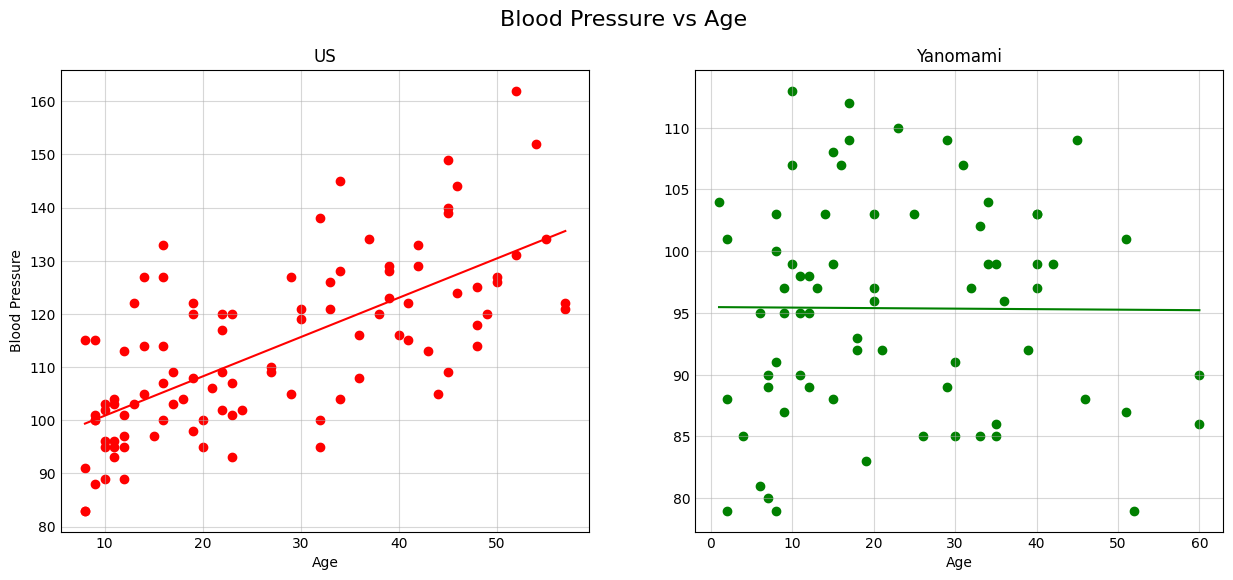

In [ ]:
plt.figure(figsize=(15, 6))
plt.suptitle('Blood Pressure vs Age', fontsize=16)

plt.subplot(1, 2, 1)
plt.scatter(us_x, us_y, color= 'red')
us_model.plot_model(x_min, x_max, color="red")
clr_visual()
plt.title('US')
plt.ylabel('Blood Pressure')

plt.subplot(1, 2, 2)
plt.scatter(yano_x, yano_y, color= 'green')
yanomami_model.plot_model(x_ymin, x_ymax, color="green")
clr_visual()
plt.title('Yanomami')

## **Comparison and Conclusions**

Best-Fit Lines: The US population shows a significant positive slope (0.74), indicating that systolic blood pressure increases by nearly 0.75 mmHg for every year of age. In contrast, the Yanomami population has a slope very close to zero (−0.004), meaning their blood pressure remains remarkably stable as they age.

**Goodness of Fit:** The R2 value for the US model (0.472) suggests that age is a moderately strong predictor of blood pressure in the US. However, the R2 for the Yanomami model is effectively zero, indicating that age has no predictive power over blood pressure in their society.

**Conclusions:** The data suggests that the "natural" state of human aging does not necessarily include a rise in blood pressure. The steady increase seen in the US population is likely a result of environmental or lifestyle factors rather than biological aging alone.

## **Confounding Variables and Salt Intake**

Does this data prove salt intake causes these differences? No, this data alone does not prove causation. While the INTERSALT study suggests a strong link between high salt consumption and hypertension, our specific dataset only shows a correlation between age and blood pressure across two different cultures. We do not have individual salt intake data for these participants to establish a direct causal link.

**Potential Confounding Factors:** Several other factors could explain why the Yanomami do not experience age-related hypertension:

**Physical Activity:** The Yanomami lead a physically demanding hunter-gatherer lifestyle compared to the more sedentary lifestyle common in the US.

**Dietary Quality:** Beyond salt, the Yanomami diet is high in fiber and low in processed sugars and saturated fats.

**Stress Levels:** The social structures and stressors of a traditional society differ vastly from those of a modern industrial society.

**Body Mass Index (BMI):** Obesity is rare in Yanomami populations, whereas it is a significant contributor to hypertension in the US.

**Genetics:** While environmental factors are likely dominant, genetic differences between the populations could also play a role.